# Analyse complète des résultats — Classification Supervisée

> Voir `DEMARCHE.md` pour le guide complet d'utilisation (ordre des notebooks, cas Y binaire vs Y quantitative, description des modules `.py`).

**Prérequis** :
1. `01_preparation.ipnyb` exécuté → `dfbase.csv`, `dfpoly.csv`, `dfinter.csv`, `dffull.csv`
2. `02_ComparaisonCS_final.ipynb` exécuté → `PROB.csv`, `PROBpoly.csv`, `PROBinter.csv`, `PROBfull.csv`

**Ce notebook** :
- Calcule accuracy, sensibilité, spécificité, F1 aux seuils 0.5 et naturel
- Compare les 3 jeux de features si demandé
- Trace les **courbes ROC** et calcule les **AUC**
- Sélection des **variables importantes** par stabilité bootstrap (Lasso + ElasticNet logistiques)

In [ ]:
#import sys
#!{sys.executable} -m pip install scikit-learn pandas numpy matplotlib patsy statsmodels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as sklm
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
import statsmodels.formula.api as smf
import os
import warnings
warnings.filterwarnings("ignore")

# ← Modifier si les fichiers sont ailleurs
DOSSIER_PROB    = "../FICHIERS FINAUX/"
DOSSIER_DONNEES = "../FICHIERS FINAUX/DONNEES/"
FICHIER_BASE    = DOSSIER_PROB + "dfbase.csv"

GRAINE   = 42
skf      = StratifiedKFold(n_splits=10, shuffle=True, random_state=GRAINE)
GRILLE_C = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
COULEURS = ["steelblue", "tomato", "seagreen", "darkorange",
            "mediumpurple", "saddlebrown", "deeppink", "grey"]

In [2]:
# ← Choisir le(s) jeu(x) de features à analyser parmi : "base", "poly", "inter"
JEUX_ACTIFS = ["base"]                      # un seul
# JEUX_ACTIFS = ["base", "poly"]            # deux
# JEUX_ACTIFS = ["base", "poly", "inter"]   # les trois

## 1. Chargement des probabilités prédites (PROB.csv)

In [3]:
fichiers = {
    "base":  DOSSIER_PROB + "PROB.csv",
    "poly":  DOSSIER_PROB + "PROBpoly.csv",
    "inter": DOSSIER_PROB + "PROBinter.csv"
}

probs = {}
for nom in JEUX_ACTIFS:
    if nom not in fichiers:
        print(f"NOM INCONNU : {nom!r}  —  valeurs possibles : {list(fichiers)}")
        continue
    chemin = fichiers[nom]
    if os.path.exists(chemin):
        probs[nom] = pd.read_csv(chemin)
        print(f"Chargé {chemin} -> {probs[nom].shape}")
    else:
        print(f"FICHIER MANQUANT : {chemin}")
        print("  Relancer ComparaisonCS_final.ipynb avec le bon dfXXX.csv et sauvegarder le bon PROB*.csv")

premier = next(iter(probs.values()), None)
if premier is not None:
    print("\nMéthodes disponibles :", list(premier.columns[1:]))
    print(f"Proportion Y=1 : {premier.Y.mean():.1%}")

FICHIER MANQUANT : ../FICHIERS FINAUX/PROB.csv
  Relancer ComparaisonCS_final.ipynb avec le bon dfXXX.csv et sauvegarder le bon PROB*.csv


## 2. Fonction de calcul des indicateurs de performance

| Contexte	| Métrique recommandée | 
|---|---| 
| Classes équilibrées	| Accuracy | 
| Ne pas rater un cas positif (médecine)	| Sensibilité | 
| Éviter les fausses alertes	| Spécificité | 
| Classes déséquilibrées	| F1 | 
| Vue globale équilibrée	| Score Médecin | 

In [4]:
def compute_metrics(PROB, seuil_type="fixe"):
    """Calcule les indicateurs de performance pour chaque methode.
    
    Parameters
    ----------
    PROB : DataFrame avec colonnes Y, log, BIC, AIC, ridge, lasso, elast, arbre, foret
    seuil_type : 'fixe' (s=0.5) ou 'naturel' (s = proportion de 0 dans Y)
    
    Returns
    -------
    DataFrame : une ligne par methode, colonnes = seuil, accuracy, sensibilite, specificite, medecin, F1
    """
    noms = PROB.columns[1:]
    resultats = pd.DataFrame(index=noms)
    nbr0 = int(PROB.Y.value_counts()[0])
    
    for nom in noms:
        # 2 modèles de seuil
        if seuil_type == "naturel":
            # Trie les probabilités par ordre croissant, oupe entre la nbr0-ième et (nbr0+1)-ième valeur
            # Garantit que le modèle prédit autant de 0 que dans Y réel - Plus adapté quand les classes sont déséquilibrées
            tmp = PROB[nom].sort_values(ascending=True)
            s = (tmp.iloc[nbr0-1] + tmp.iloc[nbr0]) / 2
        else:
            s = 0.5
        
        # matrice de confusion
        y_pred = (PROB[nom] >= s).astype(int)
        conf = sklm.confusion_matrix(PROB.Y, y_pred)
        
        # définition des métriques de performance
        resultats.loc[nom, "seuil"]        = round(s, 3)
        resultats.loc[nom, "accuracy"]     = sklm.accuracy_score(PROB.Y, y_pred)        # proportion de bien classés
        resultats.loc[nom, "sensibilite"]  = conf[1,1] / (conf[1,1] + conf[1,0])        # proportion de vrais positifs
        resultats.loc[nom, "specificite"]  = conf[0,0] / (conf[0,0] + conf[0,1])        # proportion de vrais négatifs
        resultats.loc[nom, "F1"]           = sklm.f1_score(PROB.Y, y_pred)              # F1 score : Équilibre entre sensibilité et précision
        resultats.loc[nom, "medecin"]      = resultats.loc[nom, "sensibilite"] + resultats.loc[nom, "specificite"]  # sensib + spec
    
    return resultats.astype(float).round(3)

## 3. Comparaison — seuil fixe (0.5)

Comparaison des modèles selon les différents indicateurs

In [5]:
print("=" * 60)
for jeu, PROB in probs.items():
    print(f"\n--- Features : {jeu.upper()} ---")
    res = compute_metrics(PROB, seuil_type="fixe")
    print(res.sort_values("medecin", ascending=False).to_string())

## 4. Comparaison — seuil naturel
Le seuil naturel est calculé pour que le nombre d'individus classés positifs soit égal au nombre réel de positifs.  
C'est le seuil recommandé en pratique car il respecte la prévalence observée.

In [6]:
print("=" * 60)
for jeu, PROB in probs.items():
    print(f"\n--- Features : {jeu.upper()} ---")
    res = compute_metrics(PROB, seuil_type="naturel")
    print(res.sort_values("medecin", ascending=False).to_string())

## 5. Synthèse — critère 'médecin' (sensibilité + spécificité)

In [7]:
records = []
for jeu, PROB in probs.items():
    res = compute_metrics(PROB, seuil_type="naturel")
    for methode in res.index:
        records.append({
            "features":    jeu,
            "methode":     methode,
            "seuil":       res.loc[methode, "seuil"],
            "accuracy":    res.loc[methode, "accuracy"],
            "sensibilite": res.loc[methode, "sensibilite"],
            "specificite": res.loc[methode, "specificite"],
            "F1":          res.loc[methode, "F1"],
            "medecin":     res.loc[methode, "medecin"]
        })

synthese = pd.DataFrame(records)
print("Top 10 combinaisons par critere 'medecin' (seuil naturel) :")
print(synthese.sort_values("medecin", ascending=False).head(10).to_string(index=False)) # meilleure combinaison globale selon KPI medecin

pivot = synthese.pivot(index="methode", columns="features", values="medecin")
print("\nPivot medecin (methode x features) :")
print(pivot.round(3).to_string())

Top 10 combinaisons par critere 'medecin' (seuil naturel) :


KeyError: 'medecin'

## 6. Visualisation — critère médecin par méthode

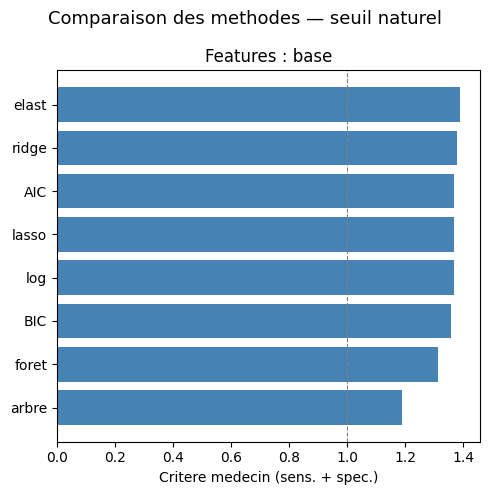

In [31]:
fig, axes = plt.subplots(1, len(probs), figsize=(5 * len(probs), 5), sharey=True)
if len(probs) == 1:
    axes = [axes]

for ax, (jeu, PROB) in zip(axes, probs.items()):
    res = compute_metrics(PROB, seuil_type="naturel").sort_values("medecin", ascending=True)
    ax.barh(res.index, res["medecin"], color="steelblue")
    ax.set_title(f"Features : {jeu}")
    ax.set_xlabel("Critere medecin (sens. + spec.)")
    ax.axvline(x=1.0, color="grey", linestyle="--", linewidth=0.8)

plt.suptitle("Comparaison des methodes — seuil naturel", fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Courbes ROC et AUC
La courbe ROC trace la **sensibilité** en fonction de **(1 − spécificité)** pour tous les seuils possibles.
Elle compare les méthodes **indépendamment du seuil choisi**.

- **AUC = 1.0** → classifieur parfait
- **AUC = 0.5** → aléatoire (diagonale)
- Avantage sur les métriques précédentes : pas de dépendance au choix de seuil

In [32]:
# Tableau des AUC
auc_records = []
for jeu, PROB in probs.items():
    for m in PROB.columns[1:]:
        auc_val = roc_auc_score(PROB.Y, PROB[m])
        auc_records.append({"features": jeu, "methode": m, "AUC": round(auc_val, 4)})

auc_df  = pd.DataFrame(auc_records)
auc_piv = auc_df.pivot(index="methode", columns="features", values="AUC")
auc_piv["moyenne"] = auc_piv.mean(axis=1).round(4)

print("AUC par methode et jeu de features (1 = parfait, 0.5 = aleatoire) :")
print(auc_piv.sort_values("moyenne", ascending=False).to_string())

AUC par methode et jeu de features (1 = parfait, 0.5 = aleatoire) :
features    base  moyenne
methode                  
ridge     0.7780   0.7780
elast     0.7760   0.7760
log       0.7729   0.7729
AIC       0.7720   0.7720
BIC       0.7715   0.7715
lasso     0.7677   0.7677
foret     0.7348   0.7348
arbre     0.6448   0.6448


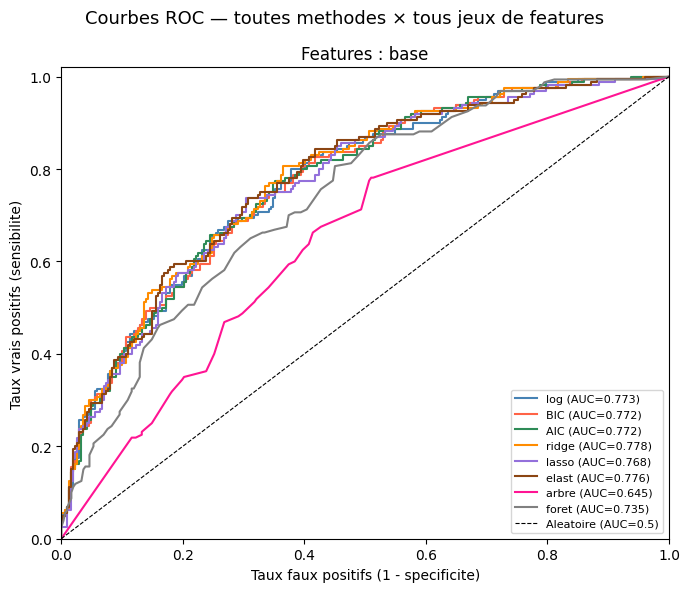

In [33]:
n = len(probs)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 6), sharey=True)
if n == 1:
    axes = [axes]

for ax, (jeu, PROB) in zip(axes, probs.items()):
    methodes = PROB.columns[1:]
    for methode, couleur in zip(methodes, COULEURS):
        fpr, tpr, _ = roc_curve(PROB.Y, PROB[methode])
        auc_val = roc_auc_score(PROB.Y, PROB[methode])
        ax.plot(fpr, tpr, label=f"{methode} (AUC={auc_val:.3f})", color=couleur, linewidth=1.5)

    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Aleatoire (AUC=0.5)")
    ax.set_xlabel("Taux faux positifs (1 - specificite)")
    ax.set_ylabel("Taux vrais positifs (sensibilite)")
    ax.set_title(f"Features : {jeu}")
    ax.legend(loc="lower right", fontsize=8)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle("Courbes ROC — toutes methodes × tous jeux de features", fontsize=13)
plt.tight_layout()
plt.show()

Meilleure combinaison : methode=ridge, features=base, AUC=0.778


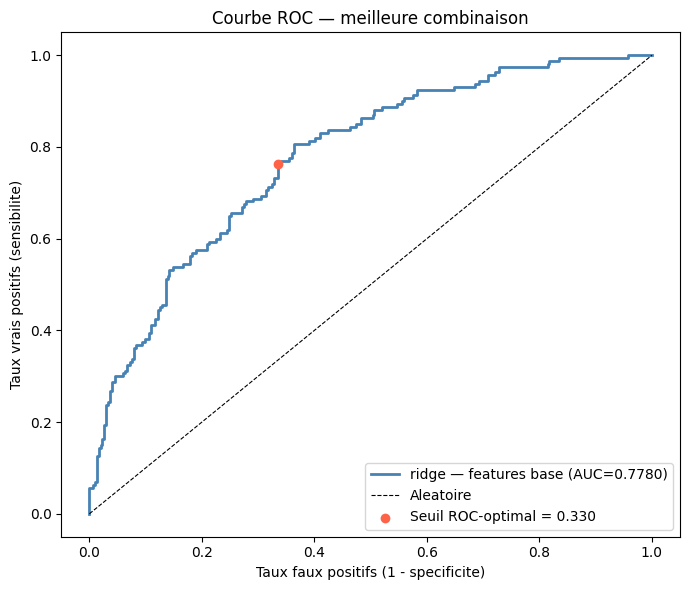

Seuil ROC-optimal : 0.3300
  Sensibilite : 0.762   Specificite : 0.666
(Comparaison avec le seuil naturel ci-dessus : ils peuvent differer)


In [34]:
# Zoom sur la meilleure combinaison (AUC max)
meilleur = auc_df.sort_values("AUC", ascending=False).iloc[0]
print(f"Meilleure combinaison : methode={meilleur.methode}, features={meilleur.features}, AUC={meilleur.AUC}")

PROB_best = probs[meilleur.features]
fpr, tpr, seuils_roc = roc_curve(PROB_best.Y, PROB_best[meilleur.methode])
auc_best = roc_auc_score(PROB_best.Y, PROB_best[meilleur.methode])

# Seuil ROC-optimal : point le plus proche du coin superieur gauche
distances = np.sqrt(fpr**2 + (1 - tpr)**2)
idx_opt = np.argmin(distances)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color="steelblue", linewidth=2,
        label=f"{meilleur.methode} — features {meilleur.features} (AUC={auc_best:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Aleatoire")
ax.scatter(fpr[idx_opt], tpr[idx_opt], color="tomato", zorder=5,
           label=f"Seuil ROC-optimal = {seuils_roc[idx_opt]:.3f}")

ax.set_xlabel("Taux faux positifs (1 - specificite)")
ax.set_ylabel("Taux vrais positifs (sensibilite)")
ax.set_title("Courbe ROC — meilleure combinaison")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Seuil ROC-optimal : {seuils_roc[idx_opt]:.4f}")
print(f"  Sensibilite : {tpr[idx_opt]:.3f}   Specificite : {1-fpr[idx_opt]:.3f}")
print("(Comparaison avec le seuil naturel ci-dessus : ils peuvent differer)")

---
## 8. Importance des variables — Sélection par stabilité (bootstrap)
**Principe** (Meinshausen & Bühlmann, 2010) : on tire `N_BOOT` échantillons bootstrap, on fitte le Lasso logistique et l'ElasticNet logistique sur chacun, et on mesure la **fréquence de sélection** de chaque variable.

- Variable sélectionnée dans **> 50 %** des bootstraps → **robuste**
- Variable sélectionnée rarement → artefact, dépend de l'échantillon

**Pourquoi Lasso et ElasticNet seulement ?**
- Lasso et ElasticNet produisent des coefficients exactement nuls → sélection binaire → comptage naturel
- Ridge : conserve toutes les variables (aucun coeff = 0) → fréquence toujours 100 % → inutile
- Forêt : pas de sélection binaire → approche différente (variance des importances)

In [35]:
don = pd.read_csv(FICHIER_BASE)
Y_imp = don["Y"].values
X_df  = don.drop(columns=["Y"])
nomsvar = list(X_df.columns)
X_imp   = X_df.values
print(f"{len(nomsvar)} variables : {nomsvar}")
print(f"{len(Y_imp)} obs, prevalence Y=1 : {Y_imp.mean():.3f}")

9 variables : ['sbp', 'tobacco', 'ldl', 'adiposity', 'typea', 'obesity', 'alcohol', 'age', 'famhist_Present']
462 obs, prevalence Y=1 : 0.346


In [36]:
from sklearn.utils import resample

N_BOOT       = 100
counts_lasso = pd.Series(0, index=nomsvar)
counts_enet  = pd.Series(0, index=nomsvar)
rng_boot     = np.random.default_rng(GRAINE)

for b in range(N_BOOT):
    seed_b = int(rng_boot.integers(0, 99999))
    X_boot, Y_boot = resample(X_imp, Y_imp, random_state=seed_b)

    # Lasso logistique
    pipe_l = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso",  LogisticRegressionCV(
                       Cs=GRILLE_C, cv=5, penalty="l1", solver="saga",
                       max_iter=2000, random_state=seed_b))
    ])
    pipe_l.fit(X_boot, Y_boot)
    counts_lasso += (pipe_l.named_steps["lasso"].coef_[0] != 0).astype(int)

    # ElasticNet logistique
    pipe_e = Pipeline([
        ("scaler", StandardScaler()),
        ("enet",   LogisticRegressionCV(
                       Cs=GRILLE_C, cv=5, penalty="elasticnet", solver="saga",
                       l1_ratios=[0.5], max_iter=2000, random_state=seed_b))
    ])
    pipe_e.fit(X_boot, Y_boot)
    counts_enet += (pipe_e.named_steps["enet"].coef_[0] != 0).astype(int)

freq_lasso = (counts_lasso / N_BOOT).sort_values(ascending=False)
freq_enet  = (counts_enet  / N_BOOT).sort_values(ascending=False)

print(f"Fréquence de sélection — bootstrap Lasso ({N_BOOT} répétitions) :")
print(freq_lasso.round(3).to_string())
print(f"\nFréquence de sélection — bootstrap ElasticNet ({N_BOOT} répétitions) :")
print(freq_enet.round(3).to_string())

Fréquence de sélection — bootstrap Lasso (100 répétitions) :
tobacco            1.00
age                1.00
famhist_Present    1.00
typea              0.99
ldl                0.98
sbp                0.80
alcohol            0.62
obesity            0.61
adiposity          0.56

Fréquence de sélection — bootstrap ElasticNet (100 répétitions) :
tobacco            1.00
age                1.00
famhist_Present    1.00
typea              0.98
ldl                0.98
sbp                0.87
obesity            0.69
alcohol            0.67
adiposity          0.64


In [37]:
# Tableau de synthèse : variables stables dans l'un ou l'autre
stab_df = pd.DataFrame({
    "freq_Lasso":   freq_lasso,
    "freq_ENet":    freq_enet,
    "stable_Lasso": (freq_lasso >= 0.5).astype(int),
    "stable_ENet":  (freq_enet  >= 0.5).astype(int),
})
stab_df["stable_les_deux"] = (
    (stab_df.stable_Lasso == 1) & (stab_df.stable_ENet == 1)
).astype(int)
stab_df = stab_df.sort_values("freq_Lasso", ascending=False)

print("Variables stables dans les DEUX méthodes (> 50%) :")
print(stab_df[stab_df.stable_les_deux == 1][["freq_Lasso", "freq_ENet"]].round(3).to_string())
print("\nTableau complet :")
print(stab_df.round(3).to_string())

Variables stables dans les DEUX méthodes (> 50%) :
                 freq_Lasso  freq_ENet
age                    1.00       1.00
tobacco                1.00       1.00
famhist_Present        1.00       1.00
typea                  0.99       0.98
ldl                    0.98       0.98
sbp                    0.80       0.87
alcohol                0.62       0.67
obesity                0.61       0.69
adiposity              0.56       0.64

Tableau complet :
                 freq_Lasso  freq_ENet  stable_Lasso  stable_ENet  stable_les_deux
age                    1.00       1.00             1            1                1
tobacco                1.00       1.00             1            1                1
famhist_Present        1.00       1.00             1            1                1
typea                  0.99       0.98             1            1                1
ldl                    0.98       0.98             1            1                1
sbp                    0.80       0.87    

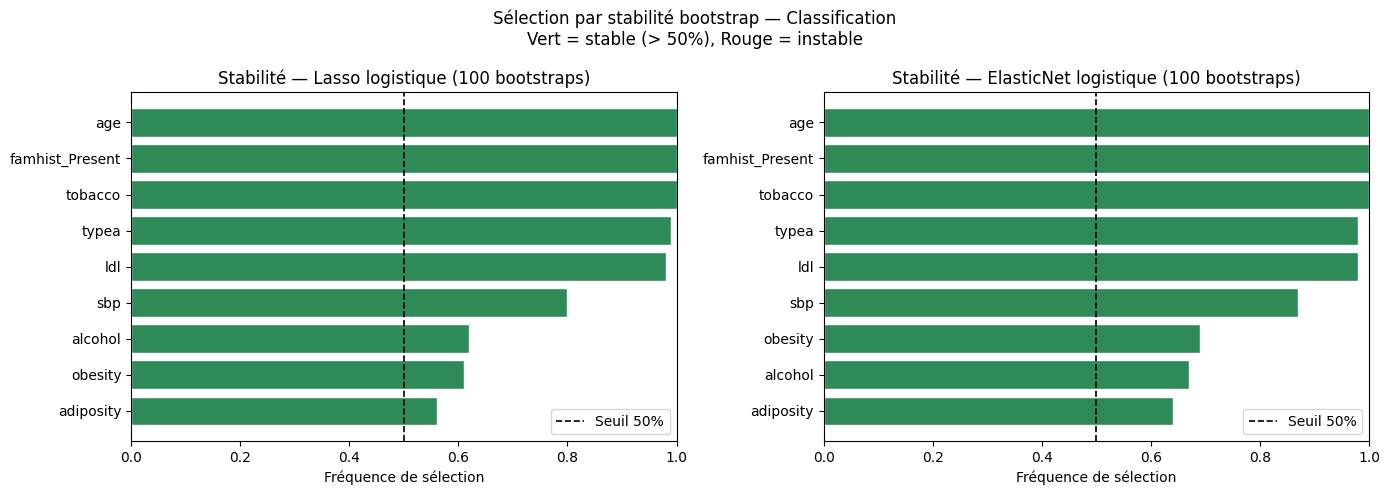

In [38]:
# Visualisation côte à côte : Lasso vs ElasticNet
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, freq, titre in [
    (ax1, freq_lasso, f"Lasso logistique ({N_BOOT} bootstraps)"),
    (ax2, freq_enet,  f"ElasticNet logistique ({N_BOOT} bootstraps)")
]:
    freq_s   = freq.sort_values(ascending=True)
    couleurs = ["seagreen" if f >= 0.5 else "tomato" for f in freq_s]
    ax.barh(freq_s.index, freq_s.values, color=couleurs, edgecolor="white")
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="Seuil 50%")
    ax.set_xlabel("Fréquence de sélection")
    ax.set_title(f"Stabilité — {titre}")
    ax.set_xlim([0, 1])
    ax.legend()

plt.suptitle("Sélection par stabilité bootstrap — Classification\nVert = stable (> 50%), Rouge = instable", fontsize=12)
plt.tight_layout()
plt.show()

In [39]:
# Variables robustes : stables dans Lasso ET ElasticNet
robustes = stab_df[stab_df.stable_les_deux == 1].index.tolist()
print(f"Variables robustes (stables Lasso ET ElasticNet, {N_BOOT} bootstraps) :")
for v in robustes:
    print(f"  {v:20s}  Lasso={freq_lasso[v]:.0%}  ENet={freq_enet[v]:.0%}")

Variables robustes (stables Lasso ET ElasticNet, 100 bootstraps) :
  age                   Lasso=100%  ENet=100%
  tobacco               Lasso=100%  ENet=100%
  famhist_Present       Lasso=100%  ENet=100%
  typea                 Lasso=99%  ENet=98%
  ldl                   Lasso=98%  ENet=98%
  sbp                   Lasso=80%  ENet=87%
  alcohol               Lasso=62%  ENet=67%
  obesity               Lasso=61%  ENet=69%
  adiposity             Lasso=56%  ENet=64%


## 9. Conclusion
Compléter après exécution :

**Données et features utilisés :**
- Fichier source : ...
- Jeu(x) de features analysés (`JEUX_ACTIFS`) : ...

**Performances (critère médecin = sensibilité + spécificité, seuil naturel) :**
- Meilleure méthode : ... (médecin = ...)
- Meilleure méthode (AUC) : ... (AUC = ...)
- Meilleur jeu de features : ...

**Variables robustes (bootstrap, seuil 50%) :**
- Stables Lasso ET ElasticNet : ...
- Interprétation métier : ...